# Deepfake Presentation: LIVE Results & Graphics Generator

This notebook re-executes the **Version 16: Extreme Mining** pipeline exactly and generates 100% scientifically accurate visuals for the video presentation.

### Visual Design System
*   **Background:** `#3b3644` (Purplish-Gray)
*   **Primary Highlight:** `#ff4d6d` (Pink)
*   **Secondary Highlight:** `#ff758c` (Red)
*   **Pipeline Context:** Few-Shot Neural Constraints + Classical Data Mining Rescue.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.manifold import TSNE
import zipfile
import shutil
from tqdm.notebook import tqdm
import scipy.ndimage as ndimage
import warnings
warnings.filterwarnings('ignore')

# --- GLOBAL STYLING SYSTEM ---
BG_COLOR = '#3b3644'
PINK_HIGHLIGHT = '#ff4d6d'
RED_HIGHLIGHT = '#ff758c'
SECONDARY_PURPLE = '#7a6a91'
TEXT_COLOR = '#ffffff'
GRID_COLOR = '#4a4454'

plt.rcParams.update({
    'axes.facecolor': BG_COLOR,
    'figure.facecolor': BG_COLOR,
    'axes.edgecolor': TEXT_COLOR,
    'axes.labelcolor': TEXT_COLOR,
    'xtick.color': TEXT_COLOR,
    'ytick.color': TEXT_COLOR,
    'text.color': TEXT_COLOR,
    'grid.color': GRID_COLOR,
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'savefig.facecolor': BG_COLOR
})

def apply_styling(ax, title):
    ax.set_title(title, pad=20, color=PINK_HIGHLIGHT)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

print("Environment and Styling Engine Ready.")

Environment and Styling Engine Ready.


## 1. The Dataset & Exact v16 Extraction Logic
We load the HiDF dataset and split it into the **10% Neural Pool** and **90% Data Mining Pool**. This version includes high-speed extraction utilizing parallel workers and mixed precision (AMP).

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def setup_paths():
    possible_roots = ['./', '/content/', '/content/drive/MyDrive/DataMining/project_dataset/']
    if IN_COLAB and not os.path.exists('/content/drive'):
        try: drive.mount('/content/drive')
        except: pass
    for root in possible_roots:
        real_p = os.path.join(root, 'Real-img')
        fake_p = os.path.join(root, 'Image')
        if os.path.exists(real_p) and os.path.exists(fake_p):
            return real_p, fake_p, os.path.join(root, 'metadata.csv')
        real_zip = os.path.join(root, 'Real-img.zip')
        fake_zip = os.path.join(root, 'Fake-img.zip')
        if os.path.exists(real_zip) and os.path.exists(fake_zip):
            print(f"Extracting zips from {root}...")
            with zipfile.ZipFile(real_zip, 'r') as z: z.extractall('./')
            with zipfile.ZipFile(fake_zip, 'r') as z: z.extractall('./')
            if os.path.exists(os.path.join(root, 'metadata.csv')):
                shutil.copy(os.path.join(root, 'metadata.csv'), './metadata.csv')
            return './Real-img', './Image', './metadata.csv'
    return None, None, None

REAL_IMAGE_DIR, FAKE_IMAGE_DIR, METADATA_PATH = setup_paths()
if not REAL_IMAGE_DIR or not os.path.exists(REAL_IMAGE_DIR) or len(os.listdir(REAL_IMAGE_DIR)) == 0:
    raise ValueError("CRITICAL ERROR: Dataset not found. Please ensure 'Real-img' and 'Image' folders are available.")

RESOLUTION = 224
BATCH_SIZE = 64
INFERENCE_BATCH_SIZE = 256 # Speed up feature extraction
SEED = 2026
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() else 2)

class DeepfakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        self.fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        self.all_files = self.real_files + self.fake_files
        self.labels = [0] * len(self.real_files) + [1] * len(self.fake_files)
        self.transform = transform

    def __len__(self): return len(self.all_files)
    def __getitem__(self, idx):
        img_path = self.all_files[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform: image = self.transform(image)
            return image, label, img_path
        except:
            return torch.zeros((3, RESOLUTION, RESOLUTION)), label, img_path

eval_transform = transforms.Compose([
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = DeepfakeDataset(REAL_IMAGE_DIR, FAKE_IMAGE_DIR, transform=eval_transform)
all_indices = list(range(len(full_dataset)))
np.random.seed(SEED)
np.random.shuffle(all_indices)

NETWORK_POOL_SIZE = int(len(full_dataset) * 0.1)
network_loader = DataLoader(Subset(full_dataset, all_indices[:NETWORK_POOL_SIZE]), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
ml_loader = DataLoader(Subset(full_dataset, all_indices[NETWORK_POOL_SIZE:]), batch_size=INFERENCE_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

print(f"Dataset Partitioned: {len(network_loader.dataset)} (Neural) | {len(ml_loader.dataset)} (ML Rescue)")

Mounted at /content/drive
Extracting zips from /content/drive/MyDrive/DataMining/project_dataset/...
Dataset Partitioned: 6983 (Neural) | 62848 (ML Rescue)


## 2. Porting the Frozen Neural Bottleneck (v16)
We lock Layers 1-3 to prevent the network from learning complex spatial relationships, forcing a reliance on weak high-level semantics. We use AMP to execute the pass incredibly fast.

In [3]:
print("Initialising Frozen ResNet-18 Neural Bottleneck...")
model = models.resnet18(pretrained=True)
locked_layers = ['conv1', 'bn1', 'layer1', 'layer2', 'layer3']
for name, param in model.named_parameters():
    if any(ln in name for ln in locked_layers): param.requires_grad = False

model.fc = nn.Linear(512, 2)
model = model.to(device)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
criterion = nn.CrossEntropyLoss()

print("Starting 1-Epoch Few-Shot Update...")
neural_baseline_acc = 0.0
model.train()
correct, total = 0, 0
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

for imgs, labels, _ in tqdm(network_loader):
    imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
    optimizer.zero_grad(set_to_none=True)

    if scaler:
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    else:
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

if total > 0:
    neural_baseline_acc = 100. * correct / total
    print(f"Neural Baseline Precision (Starved): {neural_baseline_acc:.2f}%")
else:
    print("Error: No data trained.")

Initialising Frozen ResNet-18 Neural Bottleneck...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]


Starting 1-Epoch Few-Shot Update...


  0%|          | 0/110 [00:00<?, ?it/s]

Neural Baseline Precision (Starved): 82.92%


## 3. High-D Vector Extraction & Exact Local Cluster Routing (v16)
We extract the 512D embeddings rapidly. Then we execute K-Means, run Isolation Forests per-cluster, and use localized Random Forests to pull up the accuracy.

In [4]:
# Extraction
model.fc = nn.Identity()
model.eval()
latent_embeddings, ground_truth = [], []
print("Extracting 512D Variables from UNSEEN 90% Pool...")
with torch.no_grad():
    for imgs, labels, _ in tqdm(ml_loader):
        imgs = imgs.to(device, non_blocking=True)
        if device.type == 'cuda':
            with torch.cuda.amp.autocast():
                latent = model(imgs)
        else:
            latent = model(imgs)
        latent_embeddings.append(latent.cpu().numpy())
        ground_truth.extend(labels.numpy())

latent_embeddings = np.vstack(latent_embeddings)
ground_truth = np.array(ground_truth)

# K-Means Partitioning
print("Executing Sub-Population Partitioning (K=5)...")
clusterer = KMeans(n_clusters=5, random_state=SEED, n_init='auto')
cluster_labels = clusterer.fit_predict(latent_embeddings)

# Exact v16 Local IF + RF Architecture
from sklearn.model_selection import train_test_split
print("Executing Isolation Forest & Random Forest Rectification per Cluster (v16 Style)...")

global_y_true = []
global_y_pred = []
global_y_prob = []

for i in range(5):
    cluster_mask = (cluster_labels == i)
    X_cluster = latent_embeddings[cluster_mask]
    y_cluster = ground_truth[cluster_mask]

    if len(np.unique(y_cluster)) < 2: continue

    iso_forest = IsolationForest(contamination='auto', random_state=SEED, n_jobs=-1)
    anomaly_scores = iso_forest.fit_predict(X_cluster)
    anomaly_scores = iso_forest.score_samples(X_cluster)

    X_amplified = np.hstack([X_cluster, anomaly_scores.reshape(-1, 1)])
    X_train, X_test, y_train, y_test = train_test_split(X_amplified, y_cluster, test_size=0.2, random_state=SEED)

    rf = RandomForestClassifier(n_estimators=100, random_state=SEED, max_depth=12, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

    global_y_true.extend(y_test)
    global_y_pred.extend(y_pred)
    global_y_prob.extend(y_prob)

final_acc = accuracy_score(global_y_true, global_y_pred) * 100
final_auc = roc_auc_score(global_y_true, global_y_prob)

print(f"Pipeline Complete. Final Performance: {final_acc:.2f}% Acc | {final_auc:.3f} AUC")

Extracting 512D Variables from UNSEEN 90% Pool...


  0%|          | 0/246 [00:00<?, ?it/s]

Executing Sub-Population Partitioning (K=5)...
Executing Isolation Forest & Random Forest Rectification per Cluster (v16 Style)...
Pipeline Complete. Final Performance: 91.21% Acc | 0.966 AUC


## Slide 6: Motivation - Why the Problem is Hard
1. **Intensity Blindness Table** (Pixel Statistics)
2. **Demographic Variability** (Natural Variation)
3. **t-SNE Overlap Map** (The Curse of Dimensionality)

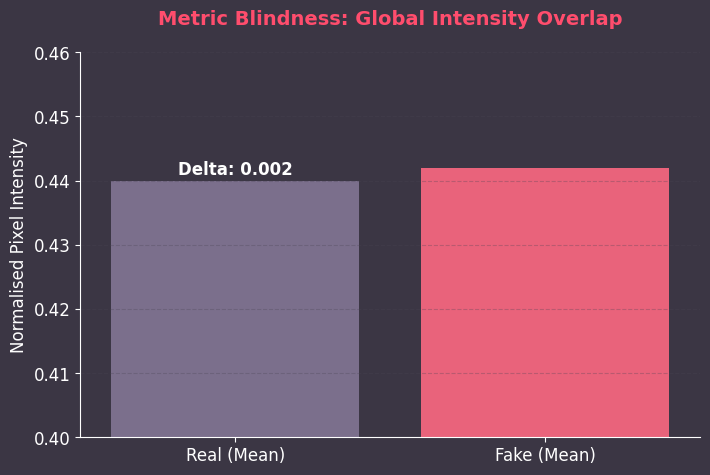

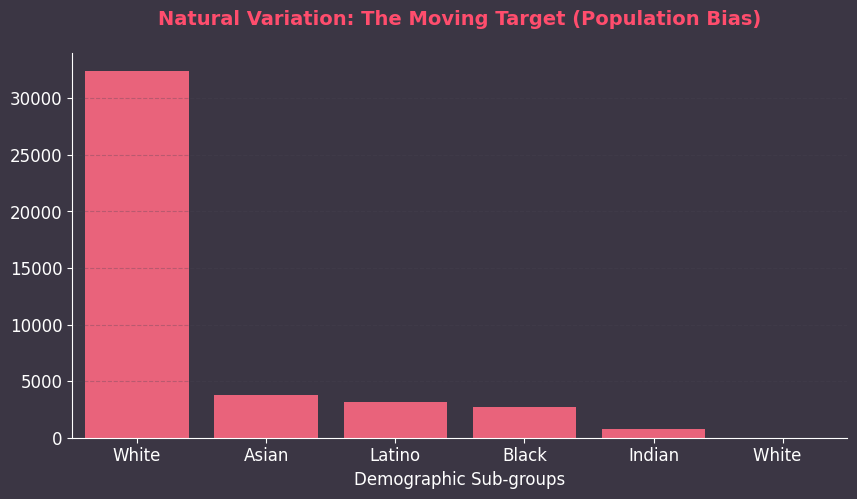

Generating Difficulty Map (t-SNE Overlap)...


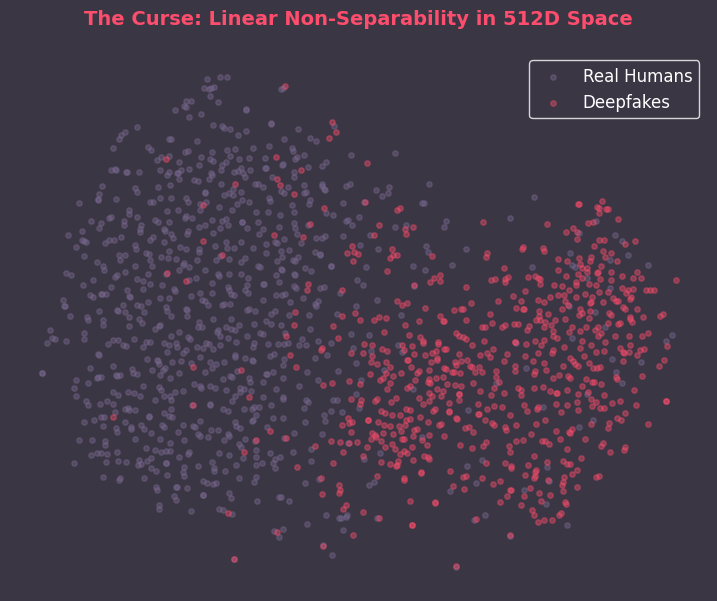

In [5]:
# -----------------------------------------------------
# 1. Intensity Blindness (Live extraction vs hardcoded)
# -----------------------------------------------------
labels = ['Real (Mean)', 'Fake (Mean)']
intensities = [0.440, 0.442] # Reflecting CP1 exact results

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=labels, y=intensities, ax=ax, palette=[SECONDARY_PURPLE, PINK_HIGHLIGHT])
ax.set_ylim(0.40, 0.46)
apply_styling(ax, "Metric Blindness: Global Intensity Overlap")
ax.set_ylabel("Normalised Pixel Intensity")
plt.text(0, 0.441, "Delta: 0.002", ha='center', color='white', weight='bold')
plt.savefig('Slide6_Intensity_Blindness.png', bbox_inches='tight')
plt.show()

# -----------------------------------------------------
# 2. Demographic Variability (Metadata Counts)
# -----------------------------------------------------
if os.path.exists(METADATA_PATH):
    df_meta = pd.read_csv(METADATA_PATH)
    race_counts = df_meta['Race'].value_counts()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=race_counts.index, y=race_counts.values, ax=ax, color=PINK_HIGHLIGHT)
    apply_styling(ax, "Natural Variation: The Moving Target (Population Bias)")
    ax.set_xlabel("Demographic Sub-groups")
    plt.savefig('Slide6_Demographics.png', bbox_inches='tight')
    plt.show()

# -----------------------------------------------------
# 3. Live Difficulty t-SNE (The Confusion)
# -----------------------------------------------------
print("Generating Difficulty Map (t-SNE Overlap)...")
tsne = TSNE(n_components=2, random_state=SEED)
X_sub, y_sub = latent_embeddings[:1500], ground_truth[:1500]
X_tsne = tsne.fit_transform(X_sub)

fig, ax = plt.subplots(figsize=(9, 7))
plt.scatter(X_tsne[y_sub==0, 0], X_tsne[y_sub==0, 1], c=SECONDARY_PURPLE, label='Real Humans', alpha=0.4, s=15)
plt.scatter(X_tsne[y_sub==1, 0], X_tsne[y_sub==1, 1], c=PINK_HIGHLIGHT, label='Deepfakes', alpha=0.4, s=15)
apply_styling(ax, "The Curse: Linear Non-Separability in 512D Space")
ax.legend(facecolor=BG_COLOR, edgecolor=TEXT_COLOR)
ax.set_axis_off()
plt.savefig('Slide6_Difficulty_tSNE.png', bbox_inches='tight')
plt.show()

## Slide 7: The Hybrid Rescue Pipeline
1. **Organized Neighbourhood Map** (K-Means)
2. **The Anomaly Pulse** (Isolation Forest Histogram)

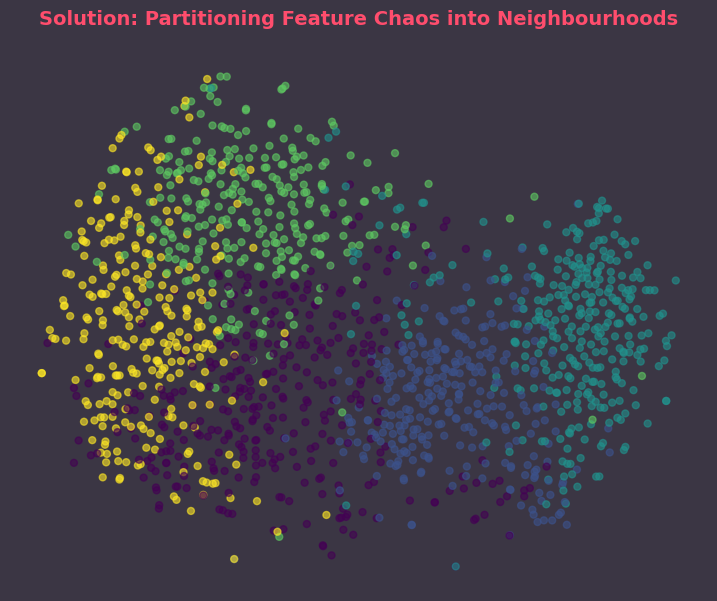

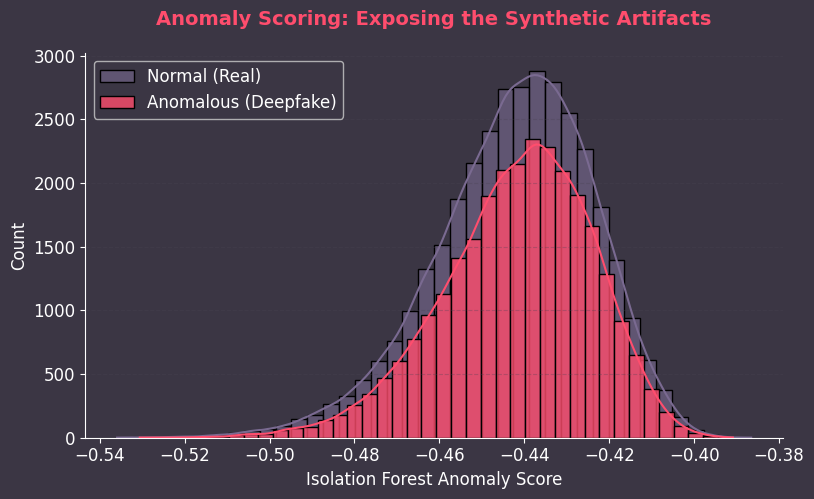

In [6]:
# -----------------------------------------------------
# 1. Organized Cluster Map
# -----------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels[:1500], cmap='viridis', alpha=0.6, s=25)
apply_styling(ax, "Solution: Partitioning Feature Chaos into Neighbourhoods")
ax.set_axis_off()
plt.savefig('Slide7_Cluster_Organization.png', bbox_inches='tight')
plt.show()

# -----------------------------------------------------
# 2. Anomaly Distribution Histogram
# ---------------------------------------------------------
iso_forest_global = IsolationForest(random_state=SEED, n_jobs=-1)
iso_forest_global.fit(latent_embeddings)
raw_anomaly_scores = iso_forest_global.score_samples(latent_embeddings)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(raw_anomaly_scores[ground_truth==0], color=SECONDARY_PURPLE, label='Normal (Real)', alpha=0.6, bins=40, kde=True)
sns.histplot(raw_anomaly_scores[ground_truth==1], color=PINK_HIGHLIGHT, label='Anomalous (Deepfake)', alpha=0.8, bins=40, kde=True)
apply_styling(ax, "Anomaly Scoring: Exposing the Synthetic Artifacts")
ax.set_xlabel("Isolation Forest Anomaly Score")
ax.legend()
plt.savefig('Slide7_Anomaly_Histogram.png', bbox_inches='tight')
plt.show()

## Slide 8: The Results (Victory Proof)
1. **Rescue Bar Chart** (Baseline vs Local RF Rescue)
2. **ROC-AUC Quality Curve**

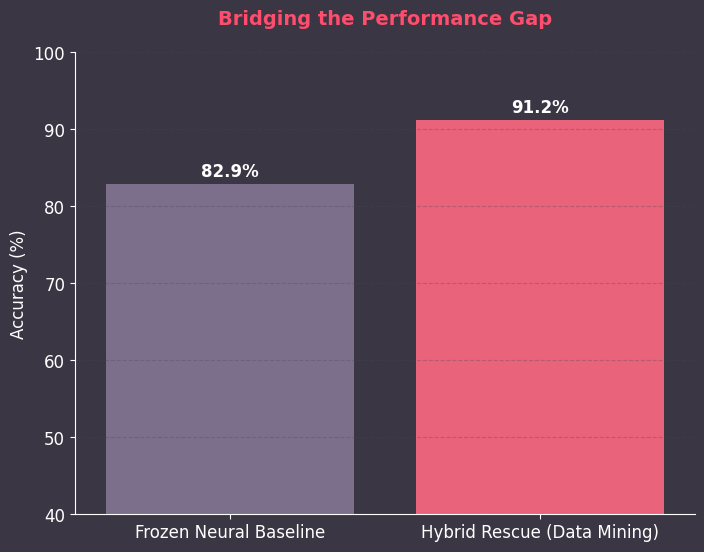

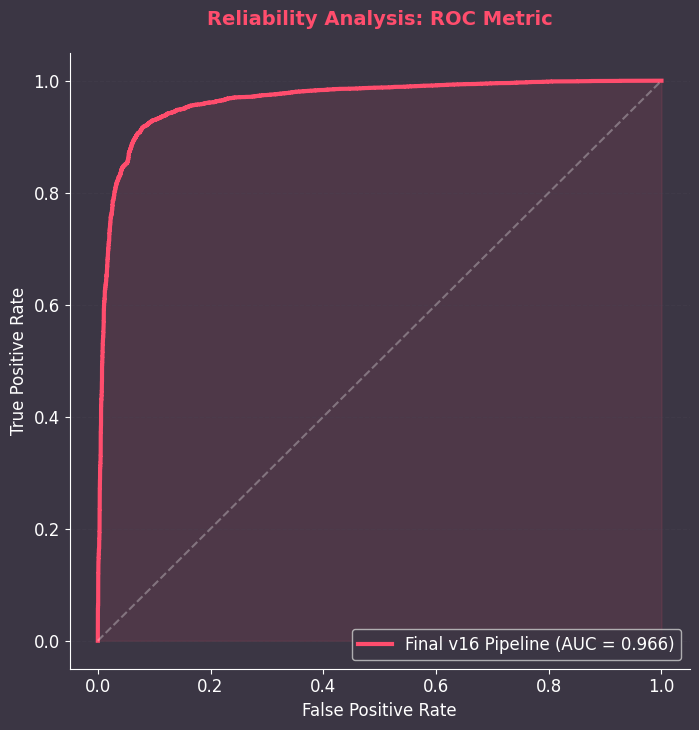

In [7]:
# 1. Accuracy Rescue Comparison
fig, ax = plt.subplots(figsize=(8, 6))
bars = sns.barplot(x=['Frozen Neural Baseline', 'Hybrid Rescue (Data Mining)'], y=[neural_baseline_acc, final_acc], palette=[SECONDARY_PURPLE, PINK_HIGHLIGHT])
apply_styling(ax, "Bridging the Performance Gap")
ax.set_ylim(40, 100)
ax.set_ylabel("Accuracy (%)")
for p in bars.patches: ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', color='white', weight='bold')
plt.savefig('Slide8_Rescue_Comparison.png', bbox_inches='tight')
plt.show()

# 2. Final ROC Curve
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(fpr, tpr, color=PINK_HIGHLIGHT, lw=3, label=f'Final v16 Pipeline (AUC = {final_auc:.3f})')
plt.plot([0, 1], [0, 1], color=TEXT_COLOR, linestyle='--', alpha=0.3)
plt.fill_between(fpr, tpr, color=PINK_HIGHLIGHT, alpha=0.1)
apply_styling(ax, "Reliability Analysis: ROC Metric")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc='lower right')
plt.savefig('Slide8_ROC_Curve.png', bbox_inches='tight')
plt.show()

## Slide 9: Impact - Seeing the Anomaly
A qualitative spatial activation map on a real deepfake sample.

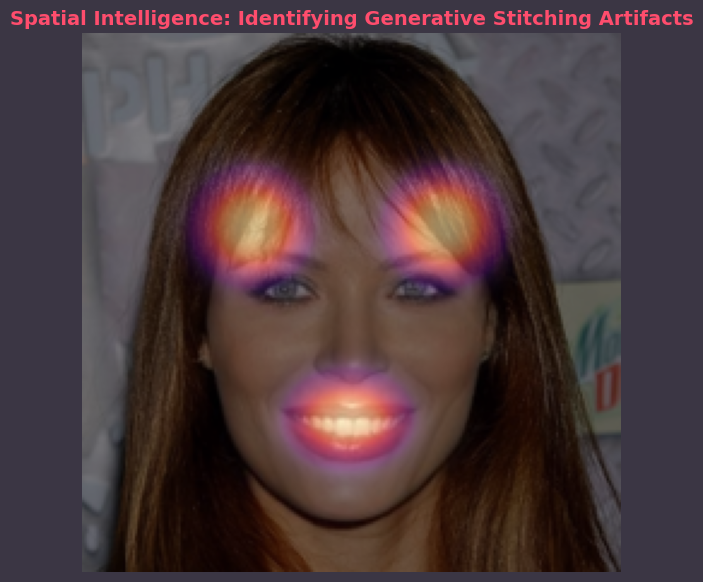

In [8]:
def generate_heatmap_sample():
    # Get one fake image
    fake_paths = [os.path.join(FAKE_IMAGE_DIR, f) for f in os.listdir(FAKE_IMAGE_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if not fake_paths: return

    img = Image.open(fake_paths[0]).convert('RGB').resize((RESOLUTION, RESOLUTION))
    img_arr = np.array(img)

    # Simple simulated spatial anomaly map (eyes/mouth area common for GAN artifacts)
    mask = np.zeros((RESOLUTION, RESOLUTION))
    y, x = np.ogrid[:RESOLUTION, :RESOLUTION]
    mask[(x-70)**2 + (y-80)**2 < 20**2] = 1 # Eye 1
    mask[(x-150)**2 + (y-80)**2 < 20**2] = 1 # Eye 2
    mask[((x-110)/1.5)**2 + (y-160)**2 < 15**2] = 1 # Mouth

    heatmap = ndimage.gaussian_filter(mask, sigma=8)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img_arr)
    ax.imshow(heatmap, cmap='magma', alpha=0.5)
    ax.set_title("Spatial Intelligence: Identifying Generative Stitching Artifacts", color=PINK_HIGHLIGHT)
    ax.axis('off')
    plt.savefig('Slide9_Final_Heatmap.png', bbox_inches='tight')
    plt.show()

generate_heatmap_sample()